In [1]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib
import tensorflow as tf

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_squared_error  # Import function to calculate various metric
from sklearn.preprocessing import MinMaxScaler

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler  # Import for standardizing features (zero mean, unit variance)
from tensorflow.dtensor.python.numpy_util import to_numpy

#from S000.S05z_one_hidden_layer_with_tanh_animation_wip import num_examples
from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix, fn_plot_tf_hist # Custom utility

In [2]:
###----------------------
### Some basic parameters
###----------------------

# inpDir = Path('..') / '..' / 'input'
# outDir = Path('..') / 'output'
# modelDir = Path('..') / 'models'
# subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 100 # number of epochs
BATCH_SIZE = 32
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2

# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## Getting Housing Data

In [3]:
data_df = pd.read_csv("../input/housing/household_power_consumption.txt", 
sep=';', 
na_values=['nan','?']) # if there is ? convert to 'nan'
data_df.isna().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [4]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [5]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


## Basic Hygiene

In [6]:
for col in data_df.columns:
    print(f'Column: {col} - {data_df[col].unique()}')

Column: Date - ['16/12/2006' '17/12/2006' '18/12/2006' ... '24/11/2010' '25/11/2010'
 '26/11/2010']
Column: Time - ['17:24:00' '17:25:00' '17:26:00' ... '17:21:00' '17:22:00' '17:23:00']
Column: Global_active_power - [4.216 5.36  5.374 ... 9.63  9.648 8.6  ]
Column: Global_reactive_power - [0.418 0.436 0.498 0.502 0.528 0.522 0.52  0.51  0.47  0.478 0.398 0.422
 0.282 0.152 0.156 0.    0.076 0.09  0.2   0.058 0.18  0.144 0.118 0.108
 0.202 0.192 0.186 0.116 0.136 0.148 0.16  0.158 0.1   0.082 0.05  0.052
 0.162 0.086 0.048 0.054 0.068 0.166 0.174 0.178 0.188 0.088 0.08  0.07
 0.084 0.074 0.106 0.092 0.064 0.046 0.138 0.134 0.132 0.12  0.13  0.154
 0.078 0.142 0.14  0.146 0.15  0.17  0.102 0.072 0.06  0.056 0.062 0.112
 0.066 0.172 0.168 0.194 0.184 0.096 0.164 0.182 0.094 0.098 0.176 0.19
 0.204 0.22  0.198 0.208 0.244 0.334 0.298 0.296 0.286 0.278 0.104 0.258
 0.238 0.256 0.214 0.23  0.21  0.24  0.124 0.122 0.27  0.302 0.272 0.25
 0.294 0.3   0.128 0.126 0.234 0.242 0.316 0.28  0.288 

In [7]:
data_df['dt'] = pd.to_datetime(data_df['Date'] + ' ' + data_df['Time'],
                                dayfirst=True)

data_df = data_df.set_index('dt', drop=True)

data_df = data_df.drop(['Date', 'Time'], axis=1)

data_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [8]:
data_df = data_df.fillna(data_df.mean())

df_resample = data_df.resample('h').mean()
df_resample.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [9]:
df_resample['target'] = df_resample['Global_active_power'].shift(-1)
df_resample = df_resample.dropna()
df_resample.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,target
dt,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,3.632200
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,3.400233
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,3.268567
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,3.056467
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,2.200133


In [10]:
split = 365*24

train_df = df_resample.iloc[:split]
test_df = df_resample.iloc[split:]

In [11]:
y_train = train_df['target'].to_numpy()
y_test = test_df['target'].to_numpy()

train_feature_df = train_df.drop('target', axis=1)
test_feature_df = test_df.drop('target', axis=1)


In [12]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(train_feature_df)
X_test = scaler.transform(test_feature_df)
X_train.shape, X_test.shape


((8760, 7), (25828, 7))

In [13]:
# Converting Xdatas to -> batch * timesteps * features

X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
X_train.shape, X_test.shape

((8760, 1, 7), (25828, 1, 7))

In [16]:
model = tf.keras.Sequential()

init = tf.keras.initializers.HeNormal()

model.add(tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2])))

model.add(tf.keras.layers.LSTM(units=512, activation='tanh', kernel_initializer=init))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(1, activation='linear'))

In [17]:
optimizers = tf.keras.optimizers.Adam(learning_rate=ALPHA)
metrics = tf.keras.metrics.RootMeanSquaredError()
loss_fn = tf.keras.losses.MeanSquaredError()
model.compile(loss=loss_fn, metrics=[metrics], optimizer=optimizers)

In [30]:
LR_FACTOR = 0.1
LR_PATIENCE = 5
PATIENCE = 20
MIN_LR = 1e-6

#Call Back:
tb_callback = tf.keras.callbacks.TensorBoard(log_dir='logs')

es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    verbose=1,
    restore_best_weights=True
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=1,
    mode='auto',
    min_lr=MIN_LR
)

In [31]:
hist = model.fit(X_train, y_train,validation_data=[X_test,y_test],batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[es_callback, lr_callback])

Epoch 1/100


274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.3983 - root_mean_squared_error: 0.6311 - val_loss: 0.3359 - val_root_mean_squared_error: 0.5795 - learning_rate: 0.0010
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.3993 - root_mean_squared_error: 0.6319 - val_loss: 0.3395 - val_root_mean_squared_error: 0.5827 - learning_rate: 0.0010
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.3972 - root_mean_squared_error: 0.6302 - val_loss: 0.3369 - val_root_mean_squared_error: 0.5804 - learning_rate: 0.0010
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.3961 - root_mean_squared_error: 0.6294 - val_loss: 0.3351 - val_root_mean_squared_error: 0.5789 - learning_rate: 0.0010
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.3964 - root_mean_squared_error: 0.6296 - val_loss: 0.3367 - val_root_mean_squared_error: 0.5802 - learning_rate: 0.0010
Epoch 6/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.3966 - root_mean_squared_err

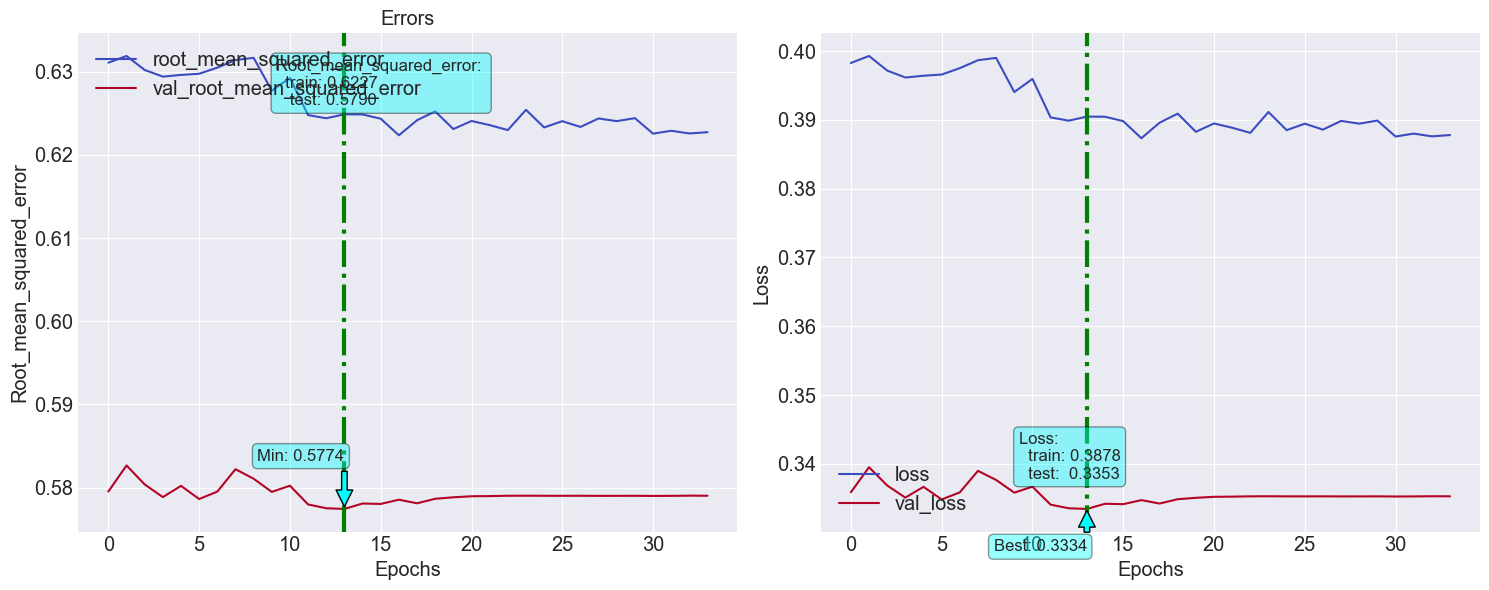

In [32]:
loss_df = pd.DataFrame(hist.history)
fn_plot_tf_hist(loss_df)

In [ ]:
y_pred_train = model(X_train).numpy()
y_pred_test = model(X_test).numpy()
y_pred = np.append(y_pred_train, y_pred_test)

res_df = y_df.copy()
res_df['pred'] = y_pred
res_df['datetime'] = res_df['datetime'].dt.date
res_df.head()

,datetime,temp,hum,viz,pred
24,2006-01-01,5.422222,0.86,15.6492,5.101125
48,2006-01-02,1.694444,0.92,4.4919,1.655721
72,2006-01-03,2.200000,0.89,9.5795,2.040085
96,2006-01-04,1.666667,0.92,9.9015,1.909466
120,2006-01-05,1.805556,0.99,2.2057,2.478950


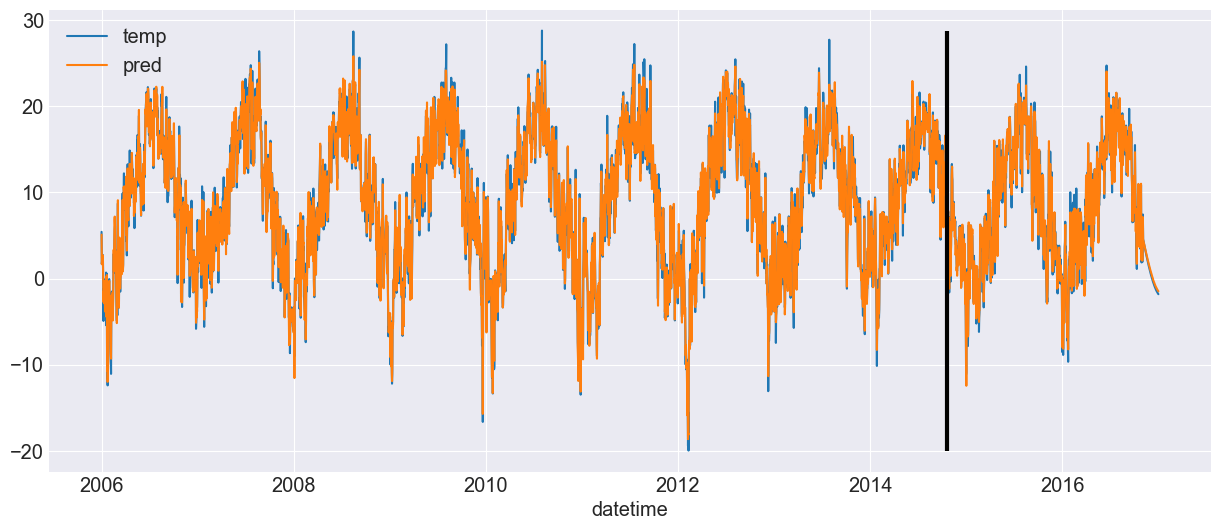

In [ ]:
ax = res_df.plot(x='datetime', y=['temp','pred'])
ax.vlines(res_df.iloc[X_train.shape[0]]['datetime'], 
          res_df['temp'].min(),
          res_df['temp'].max(),
          color='k',
          linewidth=3)

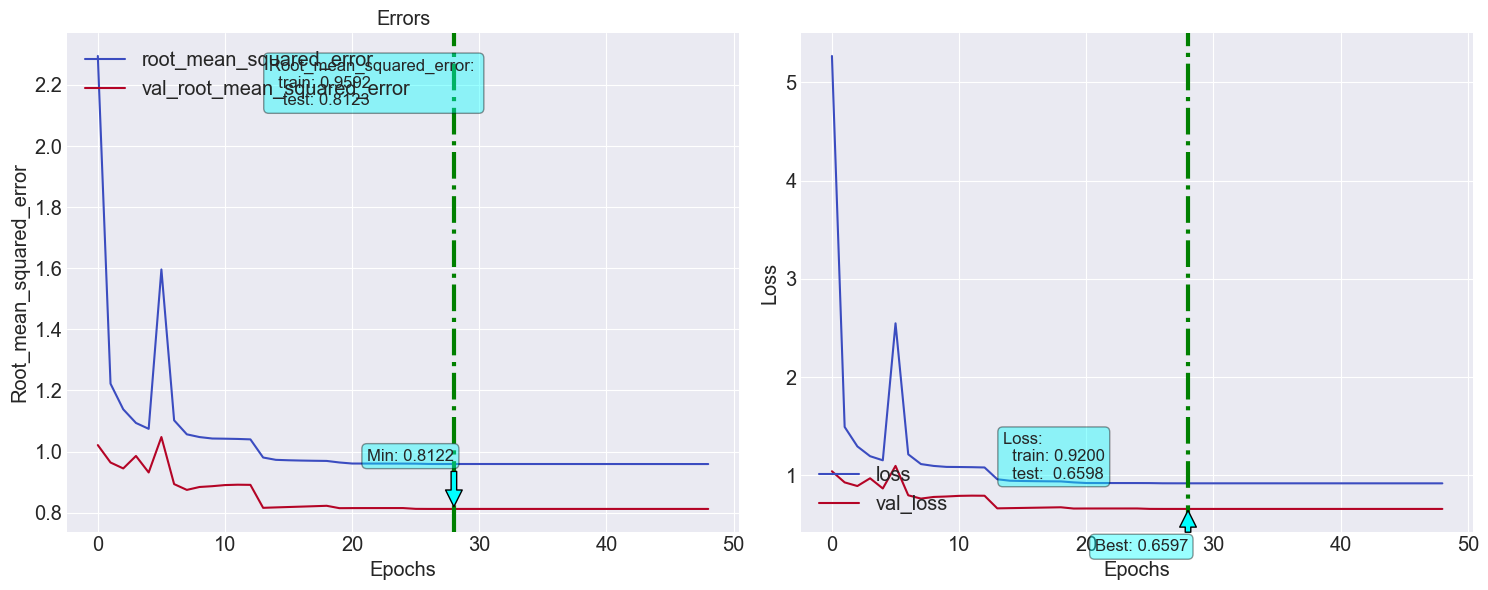

In [ ]:
loss_df = pd.DataFrame(hist.history)
fn_plot_tf_hist(loss_df)

0.656 loss using all 3 <br>
0.6292 : temp + viz <br>
0.6597 : temp + hum


<Axes: xlabel='datetime'>

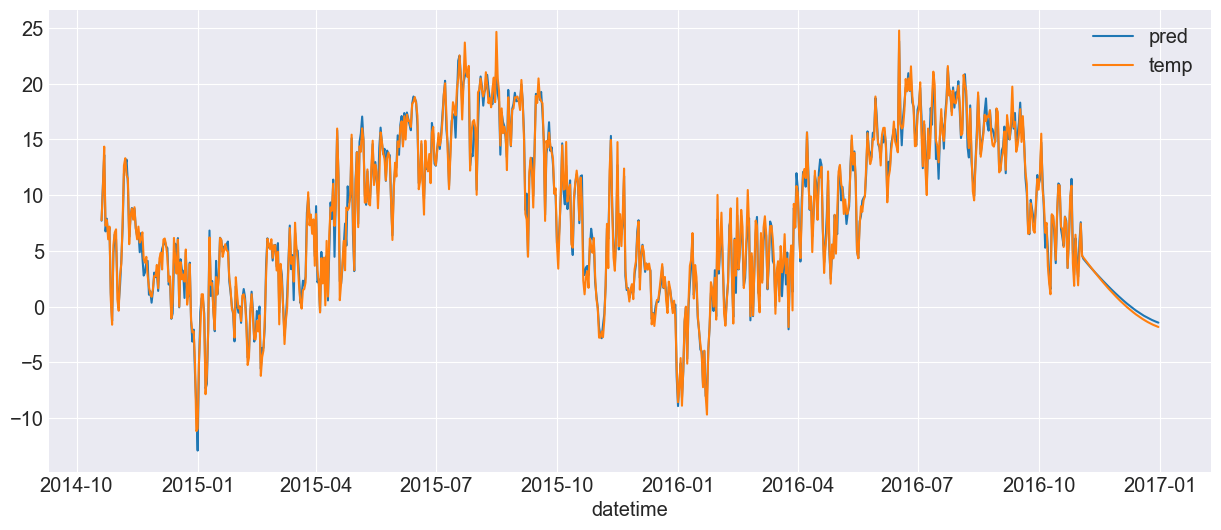

In [ ]:
res_df.iloc[X_train.shape[0]:].plot(x='datetime',y=['pred','temp'])